<a href="https://colab.research.google.com/github/vijayasrimurugan5-ui/CLASSIFICATION_USING_SNOWFLAKE/blob/main/CLASSIFICATION_USING_SNOWFLAKEipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install snowflake.connector-python pandas scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 3.0 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of pyopenssl to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 88.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 123.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.9 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3
  Attempting uninstall: pyOpenSSL
    Found

In [7]:
import pandas as pd
import snowflake.connector
conn=snowflake.connector.connect(
    user='Vijayasri13',
    password='Vijayasrimurugan13',
    account='REMANNJ-II89223',
    database='WATERPORT',
    schema='PUBLIC'
)
query='SELECT*FROM  "WATERPORT"."PUBLIC"."WATERPORT"'
df=pd.read_sql_query(query,conn)
conn.close()
print(df.head())



/tmp/ipykernel_1954/2367164831.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql_query(query,conn)


         PH    HARDNESS        SOLIDS  CHLORAMINES     SULFATE  CONDUCTIVITY  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   ORGANIC_CARBON  TRIHALOMETHANES  TURBIDITY  POTABILITY  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  


EDA

In [8]:
df.tail()

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1
3275,7.874671,195.102299,17404.177061,7.509306,NaN,327.459760,16.140368,78.698446,2.309149,1


In [9]:
df.describe()

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [10]:
df.shape

(3276, 10)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PH               2785 non-null   float64
 1   HARDNESS         3276 non-null   float64
 2   SOLIDS           3276 non-null   float64
 3   CHLORAMINES      3276 non-null   float64
 4   SULFATE          2495 non-null   float64
 5   CONDUCTIVITY     3276 non-null   float64
 6   ORGANIC_CARBON   3276 non-null   float64
 7   TRIHALOMETHANES  3114 non-null   float64
 8   TURBIDITY        3276 non-null   float64
 9   POTABILITY       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


DATA PREPROCESSING

In [12]:
df.isnull().sum()

,0
PH,491
HARDNESS,0
SOLIDS,0
CHLORAMINES,0
SULFATE,781
CONDUCTIVITY,0
ORGANIC_CARBON,0
TRIHALOMETHANES,162
TURBIDITY,0
POTABILITY,0


<Axes: >

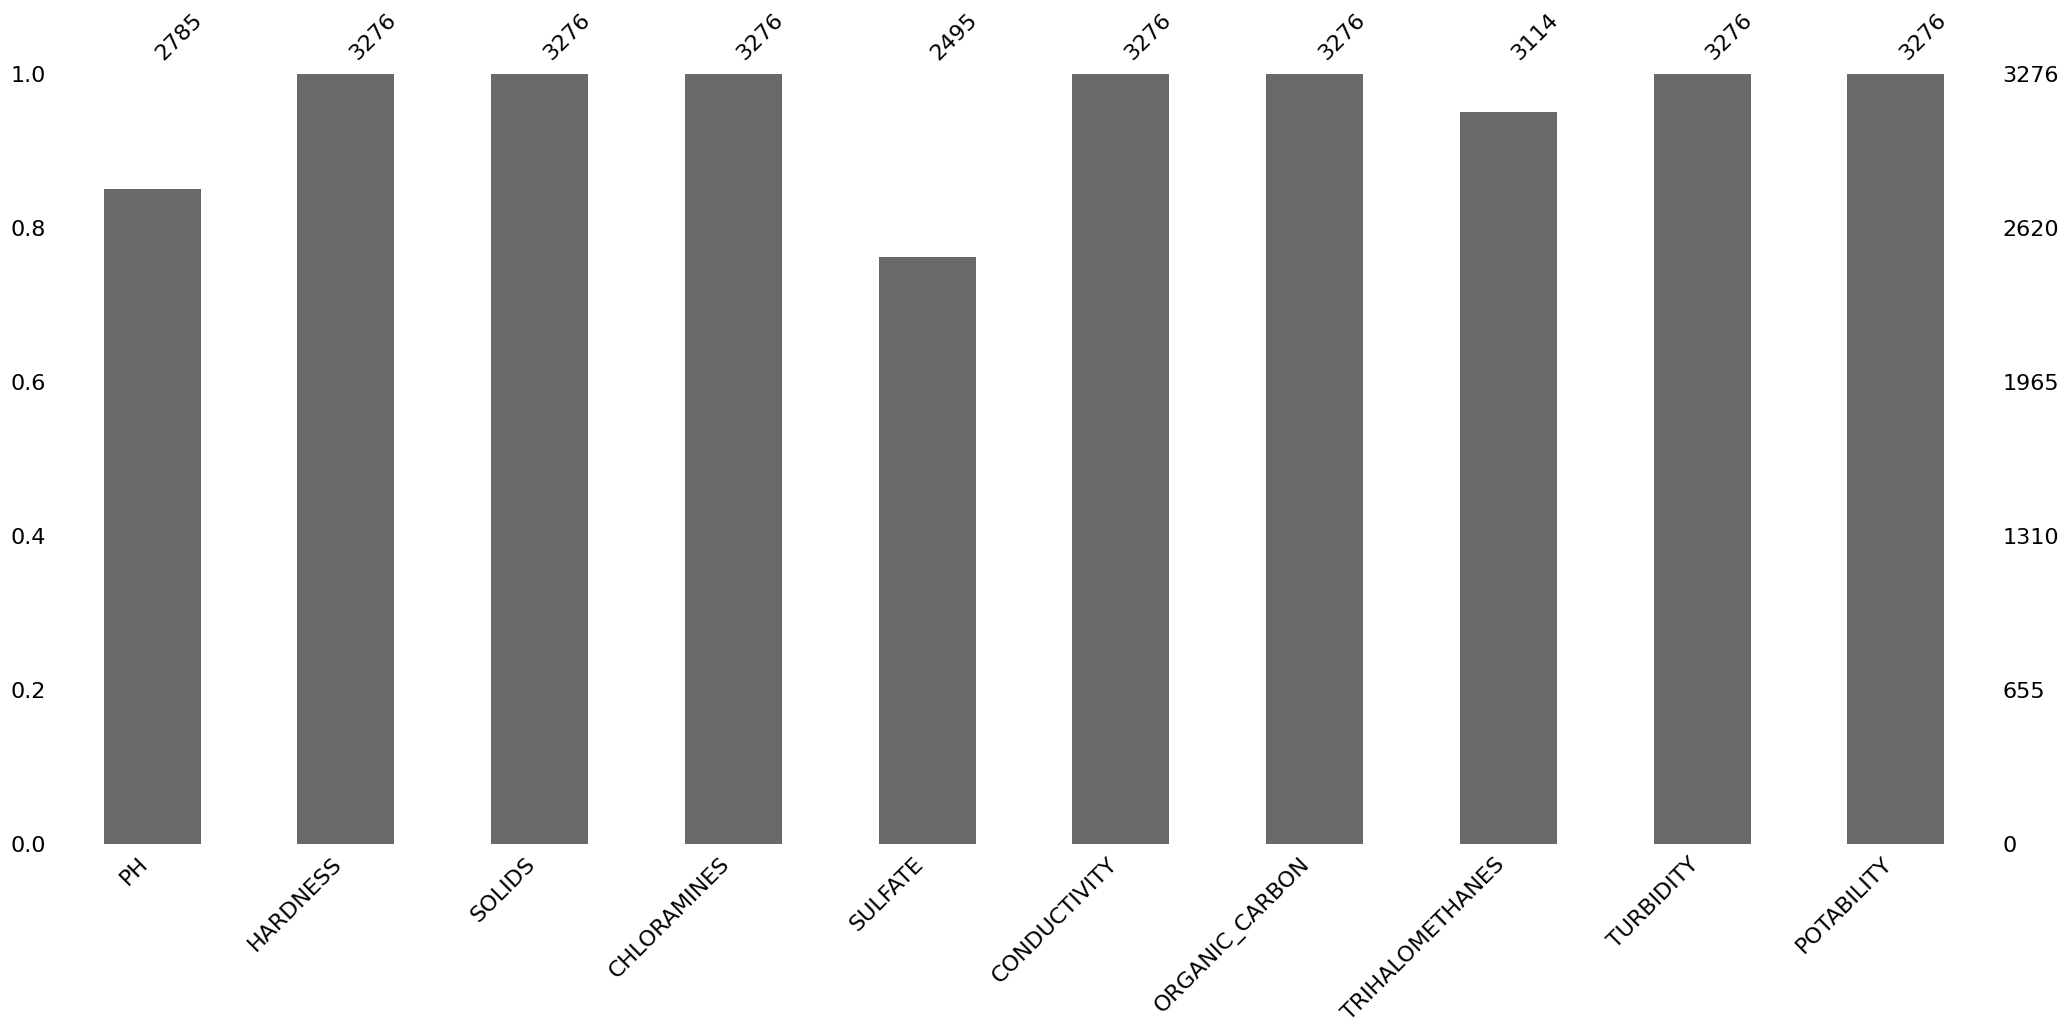

In [13]:
!pip install missingno
import missingno as msno
msno.bar(df)

<Axes: >

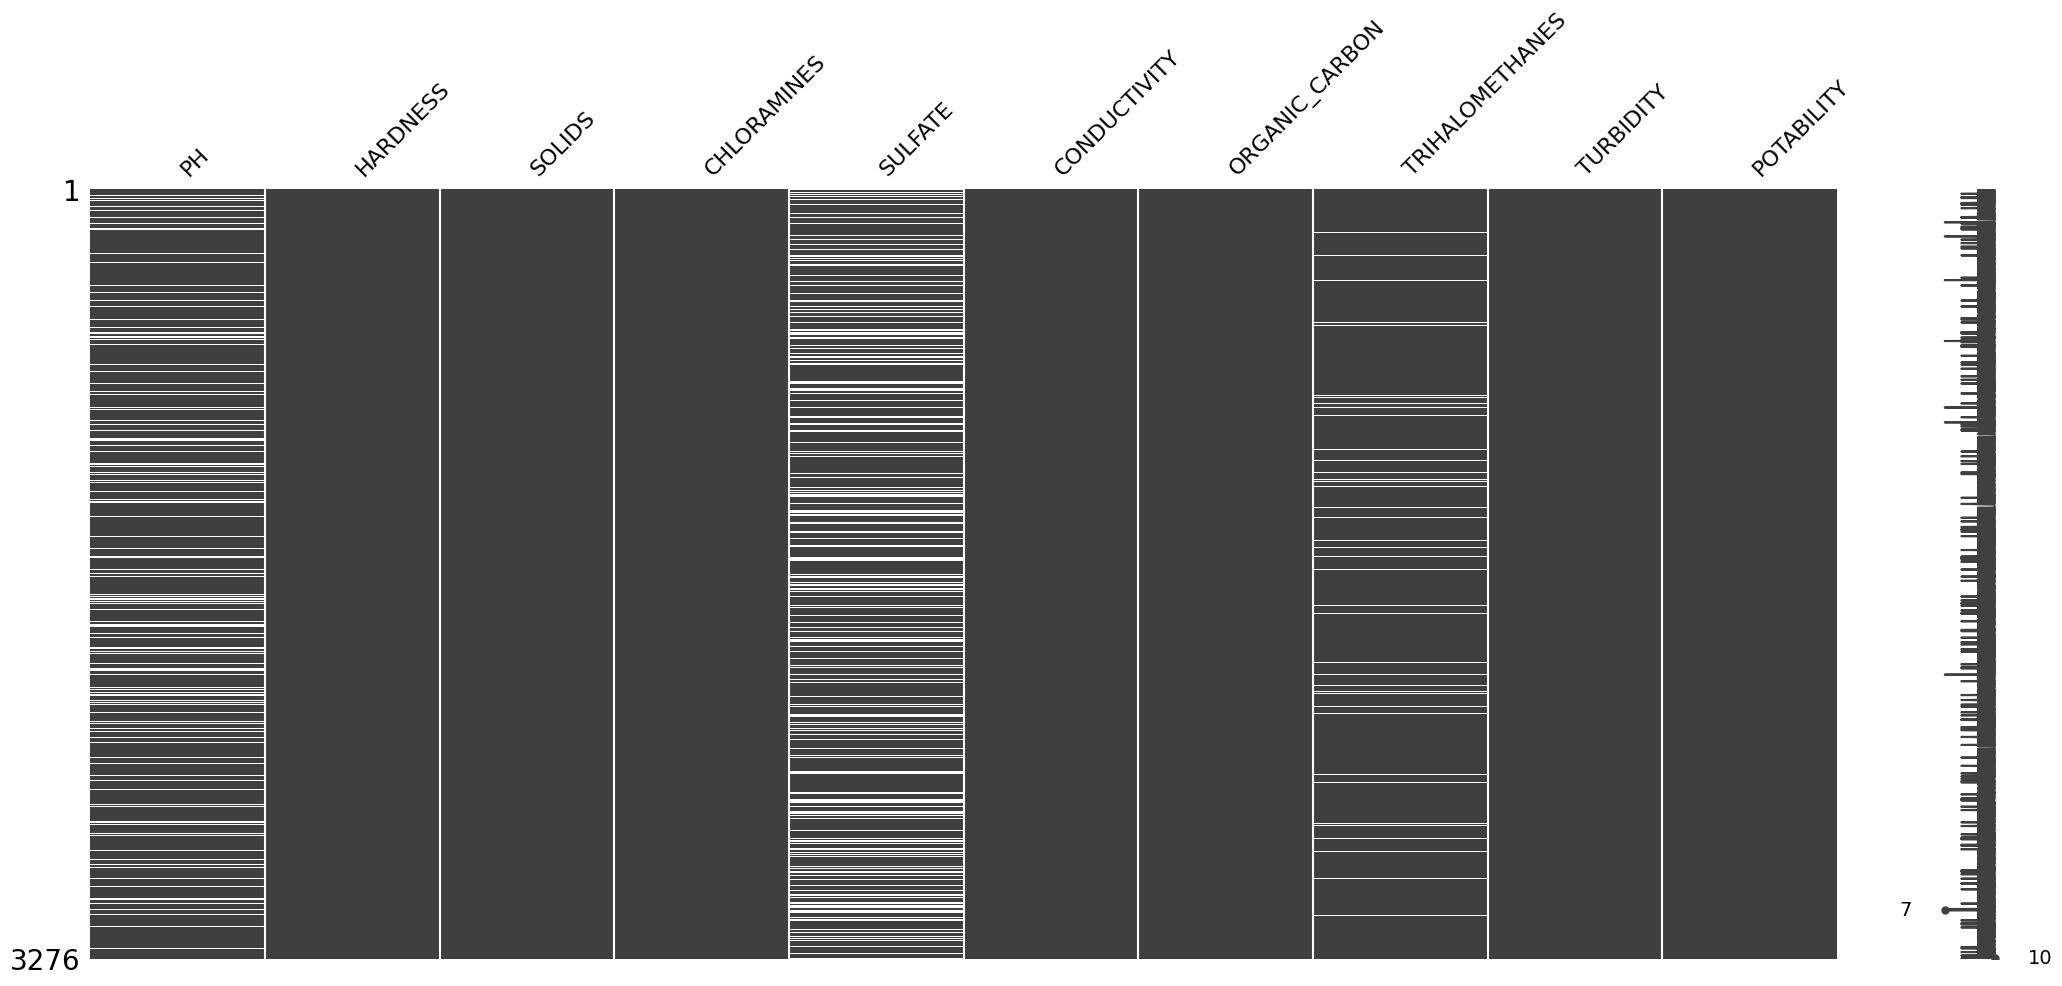

In [14]:
msno.matrix(df)

<Axes: >

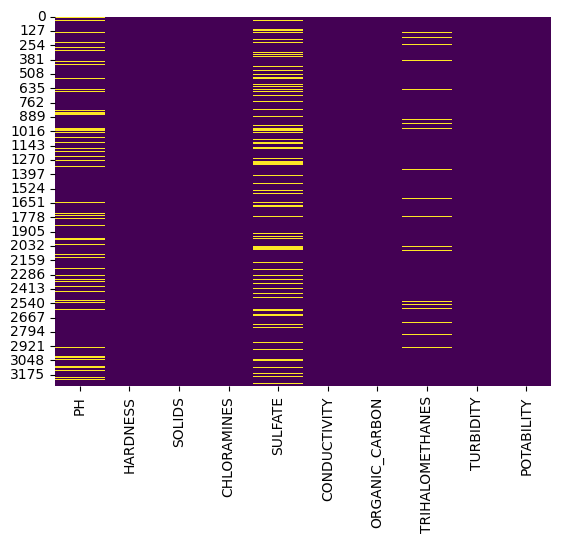

In [15]:
import seaborn as sns
sns.heatmap(df.isnull(),cbar=False,cmap='viridis')

In [16]:
from scipy.stats import zscore
import numpy as np
z_score=zscore(df)
df[np.abs(z_score)>4]

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
263,13.175402,47.432000,19237.949676,8.907020,375.147315,500.245952,12.083896,NaN,4.106924,1
285,3.882631,243.807950,7751.809491,0.530351,NaN,341.291116,12.990592,60.109968,3.734001,1
1792,NaN,230.430762,14916.986091,9.618516,NaN,379.172804,28.300000,79.633064,3.864931,0
2302,NaN,232.098339,16378.151576,0.352000,238.446564,454.555208,7.764144,55.876641,4.431829,1
2602,NaN,159.399398,61227.196008,3.713594,312.976254,377.067972,17.246698,82.197233,3.860807,0
2704,8.839584,246.066476,21179.762588,7.717662,343.047384,753.342620,16.917901,60.436032,3.118039,0


In [17]:
X=df.iloc[:,:-1]
y=df['CONDUCTIVITY'].values

In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [21]:
from sklearn.tree import DecisionTreeRegressor
model=DecisionTreeRegressor(criterion="squared_error",max_depth=3)
model.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=3)

In [22]:
y_pred=model.predict(X_test)
y_pred

array([338.96363388, 338.96363388, 378.4841323 , 414.55366869,
       491.66476038, 491.66476038, 451.95795742, 414.55366869,
       540.21329808, 414.55366869, 378.4841323 , 378.4841323 ,
       378.4841323 , 451.95795742, 414.55366869, 414.55366869,
       540.21329808, 540.21329808, 540.21329808, 414.55366869,
       338.96363388, 378.4841323 , 414.55366869, 338.96363388,
       378.4841323 , 609.66370307, 540.21329808, 491.66476038,
       491.66476038, 414.55366869, 338.96363388, 451.95795742,
       451.95795742, 540.21329808, 491.66476038, 338.96363388,
       609.66370307, 609.66370307, 491.66476038, 540.21329808,
       491.66476038, 491.66476038, 338.96363388, 338.96363388,
       540.21329808, 414.55366869, 288.6560254 , 540.21329808,
       338.96363388, 540.21329808, 338.96363388, 451.95795742,
       378.4841323 , 288.6560254 , 378.4841323 , 414.55366869,
       540.21329808, 414.55366869, 338.96363388, 414.55366869,
       609.66370307, 451.95795742, 609.66370307, 540.21

In [25]:
from sklearn.metrics import r2_score
acc=r2_score(y_test,y_pred)
print(acc)

0.969993533312967


In [27]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 186.48454459407202


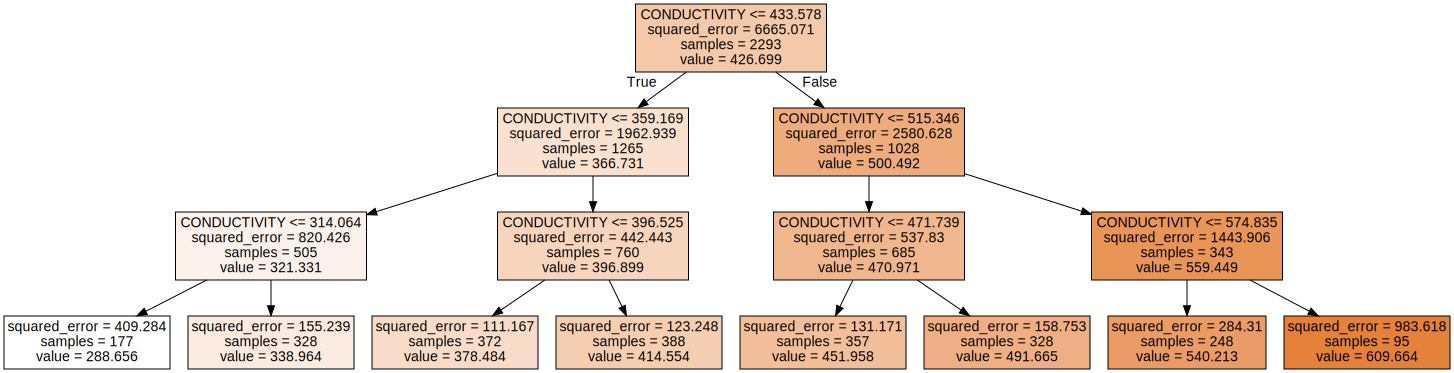

In [34]:
from sklearn.tree import export_graphviz
import graphviz
graphviz.Source(export_graphviz(model,feature_names=X.columns,filled=True))